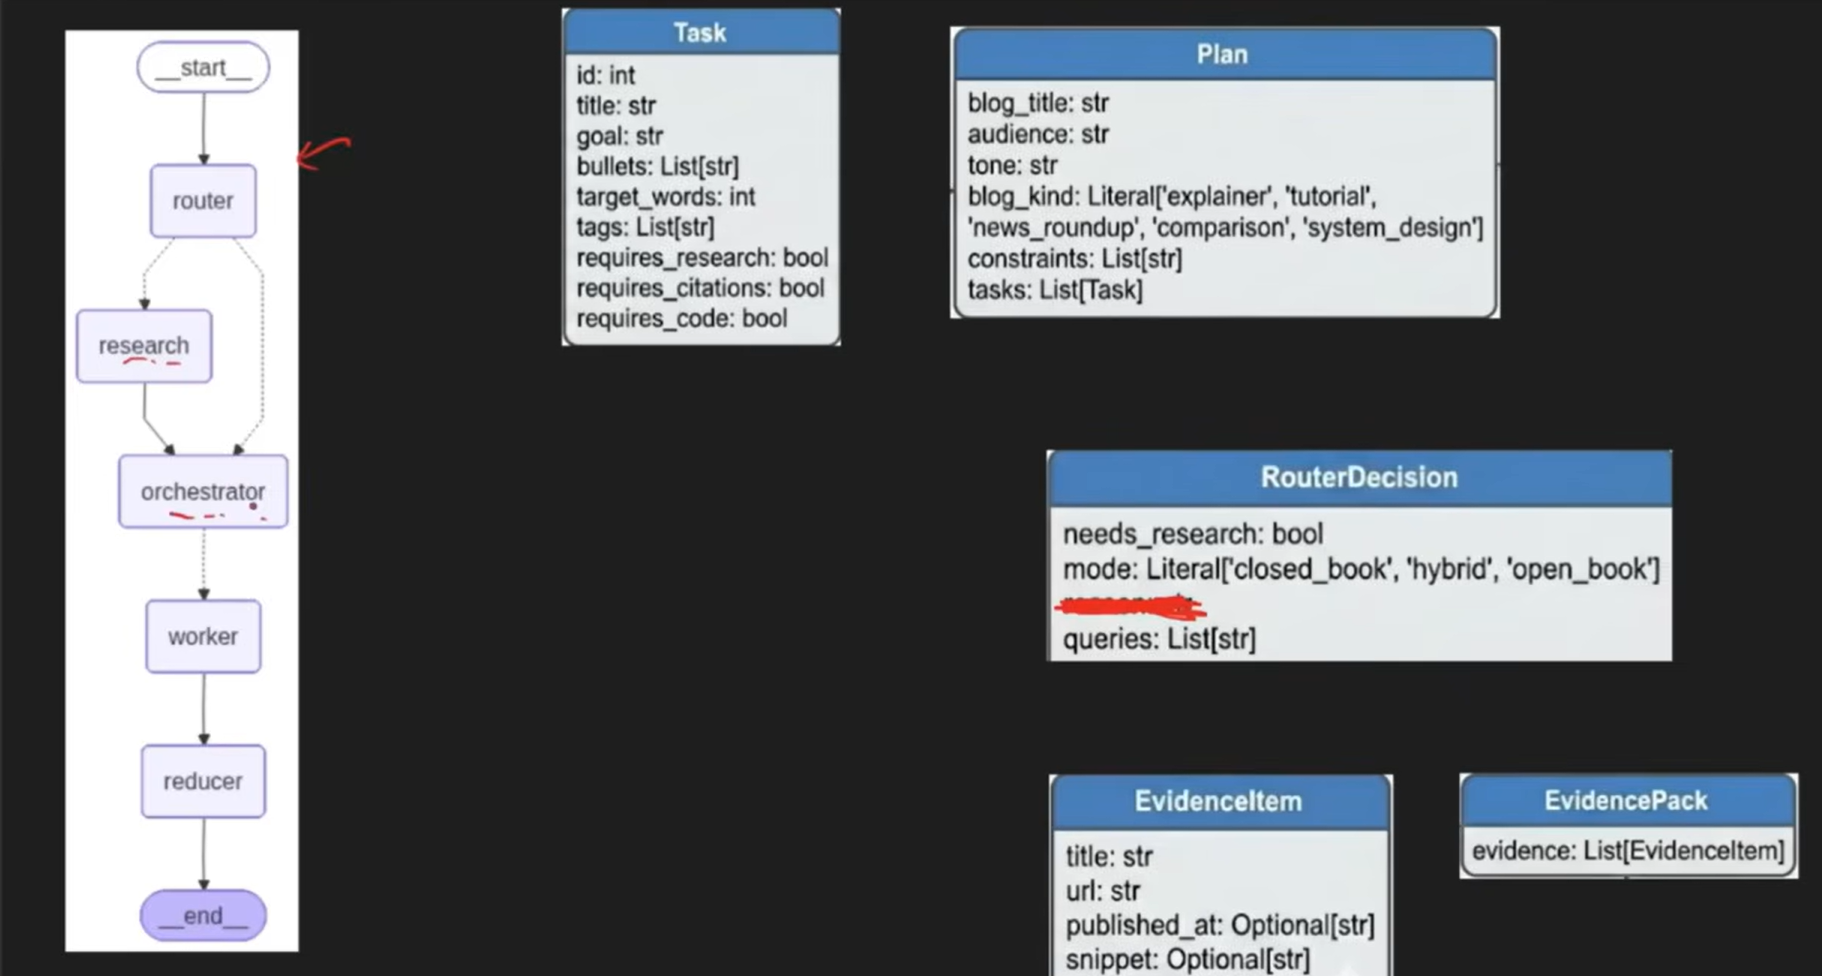

In [19]:
from __future__ import annotations

import operator
from pathlib import Path
from typing import TypedDict, List, Optional, Literal, Annotated

from pydantic import BaseModel, Field

from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage
from langchain_community.tools.tavily_search import TavilySearchResults

In [20]:
from langgraph.graph import StateGraph, START, MessagesState
from langchain_openai import ChatOpenAI
from groq import Groq
from langchain_groq import ChatGroq
from dotenv import load_dotenv
import os
from __future__ import annotations

import operator
from typing import TypedDict, List, Annotated

from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage
load_dotenv()

True

In [21]:
os.environ["LANGCHAIN_PROJECT"] = "blog writer with research agent"

In [22]:
class Task(BaseModel):
    '''
    Represents a writing task for a section of the blog post.

    Attributes:
        id: The unique identifier of the task.
        title: The title of the blog section.
        brief: A brief description of the section's content.
    '''
    id : int
    title: str = Field(..., description="The title of the blog post")
    brief: str = Field(..., description="The brief description of the blog post")
    

In [23]:
class Plan(BaseModel):
    '''
    Represents a plan for writing a blog post.
    A structured plan for generating a blog post.

    Attributes:
        blog_title: The title of the blog post.
        tasks: The ordered writing tasks required to complete the post.
    '''
    blog_title : str
    audience: str
    tasks : List[Task] = Field(..., description="The list of tasks to complete the blog post")
    


In [24]:
class EvidenceItem(BaseModel):
    title: str
    url: str
    published_at: Optional[str] = None  # keep if Tavily provides; DO NOT rely on it
    snippet: Optional[str] = None
    source: Optional[str] = None


class RouterDecision(BaseModel):
    needs_research: bool
    mode: Literal["closed_book", "hybrid", "open_book"]
    queries: List[str] = Field(default_factory=list)


class EvidencePack(BaseModel):
    evidence: List[EvidenceItem] = Field(default_factory=list)

In [25]:
class State(TypedDict):
    '''
    State represents the shared state of the blog-generation workflow.

    Attributes:
        plan: The structured plan containing the blog title and writing tasks.
        topic: The topic of the blog post.
        sections: The generated blog sections accumulated during execution.
        final: The completed blog post.
    '''
    plan: Plan
    topic : str
    mode: str
    needs_research: bool
    queries: List[str]
    evidence: List[EvidenceItem]
    plan: Optional[Plan]
    
    sections : Annotated[List[str],operator.add] = Field(description="The list of sections to be written for the blog post")
    final : str

In [26]:
llm = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0.3
)

In [27]:
ROUTER_SYSTEM = """You are a routing module for a technical blog planner.

Decide whether web research is needed BEFORE planning.

Modes:
- closed_book (needs_research=false):
  Evergreen topics where correctness does not depend on recent facts (concepts, fundamentals).
- hybrid (needs_research=true):
  Mostly evergreen but needs up-to-date examples/tools/models to be useful.
- open_book (needs_research=true):
  Mostly volatile: weekly roundups, "this week", "latest", rankings, pricing, policy/regulation.

If needs_research=true:
- Output 1-2 high-signal queries.
- Queries should be scoped and specific (avoid generic queries like just "AI" or "LLM").
- If user asked for "last week/this week/latest", reflect that constraint IN THE QUERIES.
"""

def router_node(state: State) -> dict:
    """Route the topic to research or directly to blog planning.

    Args:
        state: Current workflow state containing the topic.

    Returns:
        Routing decision with research requirement, mode, and search queries.
    """
    
    topic = state["topic"]
    decider = llm.with_structured_output(RouterDecision)
    decision = decider.invoke(
        [
            SystemMessage(content=ROUTER_SYSTEM),
            HumanMessage(content=f"Topic: {topic}"),
        ]
    )

    return {
        "needs_research": decision.needs_research,
        "mode": decision.mode,
        "queries": decision.queries,
    }

def route_next(state: State) -> str:
    """Return the next workflow node based on the research requirement.

    Args:
        state: Current workflow state containing the research decision.

    Returns:
        ``"research"`` when web research is required; otherwise,
        ``"orchestrator"``.
    """
    return "research" if state["needs_research"] else "orchestrator"


In [28]:
def _tavily_search(query: str, max_results: int = 2) -> List[dict]:
    """Run a Tavily web search and return normalized result dictionaries."""
    
    tool = TavilySearchResults(max_results=max_results)
    results = tool.invoke({"query": query})

    normalized: List[dict] = []
    for r in results or []:
        normalized.append(
            {
                "title": r.get("title") or "",
                "url": r.get("url") or "",
                "snippet": r.get("content") or r.get("snippet") or "",
                "published_at": r.get("published_date") or r.get("published_at"),
                "source": r.get("source"),
            }
        )
    return normalized

In [29]:
RESEARCH_SYSTEM = """You are a research synthesizer for technical writing.

Given raw web search results, produce a deduplicated list of EvidenceItem objects.

Rules:
- Only include items with a non-empty url.
- Prefer relevant + authoritative sources (company blogs, docs, reputable outlets).
- If a published date is explicitly present in the result payload, keep it as YYYY-MM-DD.
  If missing or unclear, set published_at=null. Do NOT guess.
- Keep snippets short.
- Deduplicate by URL.
"""

def research_node(state: State) -> dict:
    """Collect and synthesize web-based evidence for the current blog topic.

    This node executes the search queries produced by the router node, combines
    the returned search results, and uses the language model to convert them
    into validated ``EvidenceItem`` objects. Evidence is filtered to entries
    with URLs and deduplicated by URL before being returned to the workflow.

    The node returns an empty evidence list when no queries are available or
    when the searches produce no results. Search failures raised by
    ``_tavily_search`` are not suppressed and will propagate to the workflow.

    Args:
        state: The current workflow state. The ``queries`` field should contain
            the web-search queries generated by the router node.

    Returns:
        A dictionary containing ``evidence``, a list of deduplicated
        ``EvidenceItem`` objects. Each item may include its title, URL,
        publication date, snippet, and source.
    """

    # take the first 10 queries from state
    queries = (state.get("queries", []) or [])
    max_results = 2

    raw_results: List[dict] = []

    for q in queries:
        raw_results.extend(_tavily_search(q, max_results=max_results))

    if not raw_results:
        return {"evidence": []}

    extractor = llm.with_structured_output(EvidencePack)
    pack = extractor.invoke(
        [
            SystemMessage(content=RESEARCH_SYSTEM),
            HumanMessage(content=f"Raw results:\n{raw_results}"),
        ]
    )

    # Deduplicate by URL
    dedup = {}
    for e in pack.evidence:
        if e.url:
            dedup[e.url] = e

    return {"evidence": list(dedup.values())}

In [30]:
def orchestrator(state: State) -> dict:
    """
    Generate a structured blog post plan based on the topic.
    """

    print(
        f"Generating blog plan for topic: {state['topic']}"
    )
    print(state)
    evidence = state.get("evidence", [])

    evidence_text = [
        e.model_dump()
        for e in evidence
    ][:16]

    plan = llm.with_structured_output(Plan).invoke(
        [
            SystemMessage(
                content=(
                    "Create a blog plan with 1-2 sections "
                    "on the following topic."
                )
            ),

            HumanMessage(
                content=(
                    f"Topic: {state['topic']}\n"
                    f"Mode: {state['mode']}\n\n"
                    f"Evidence "
                    f"(ONLY use for fresh claims; may be empty):\n"
                    f"{evidence_text}"
                )
            )
        ]
    )

    return {
        "plan": plan
    }

In [31]:
def fanout(state: State):
    """
    Create worker tasks for each section in the generated blog plan.

    Args:
        state: The current workflow state containing the topic and blog plan.

    Returns:
        A list of Send objects that route each task to the worker node.
    """

    tasks = []

    for task in state["plan"].tasks:

        task_input = {
            "task": task,
            "topic": state["topic"],
            "mode": state["mode"],
            "evidence": [e.model_dump() for e in state.get("evidence", [])],
            "plan": state["plan"]
        }

        tasks.append(
            Send(
                "worker",
                task_input
            )
        )

    return tasks

In [32]:
WORKER_SYSTEM = """
You are a technical blog writer.

Write one clean Markdown section for the given blog.

Focus only on the assigned section.
Do not write the entire blog.
Do not add a separate conclusion unless the assigned task requires it.
"""


def worker_node(payload: dict) -> dict:
    """
    Generate one blog section based on the task assigned by fanout.
    """

    # Convert dictionaries back into Pydantic models
    task = payload["task"]
    plan = payload["plan"]

    # Convert evidence dictionaries back into EvidenceItem objects
    evidence = [
        EvidenceItem(**item)
        for item in payload.get("evidence", [])
    ]

    topic = payload["topic"]
    mode = payload.get("mode", "closed_book")

    # Format evidence
    evidence_text = ""

    if evidence:
        evidence_text = "\n".join(
            f"- {e.title} | {e.url} | "
            f"{e.published_at or 'date:unknown'}"
            for e in evidence[:20]
        )

    # Generate the section
    response = llm.invoke(
        [
            SystemMessage(
                content=WORKER_SYSTEM
            ),

            HumanMessage(
                content=(
                    f"Blog title: {plan.blog_title}\n"
                    f"Audience: {plan.audience}\n"
                    f"Topic: {topic}\n"
                    f"Mode: {mode}\n\n"

                    f"Section title: {task.title}\n"
                    f"Section brief: {task.brief}\n\n"

                    f"Evidence "
                    f"(ONLY use these URLs when citing):\n"
                    f"{evidence_text}\n"
                )
            )
        ]
    )

    section_md = response.content.strip()

    # Return task ID along with section
    # so reducer can preserve the original order
    return {
        "sections": [
            (task.id, section_md)
        ]
    }

In [36]:
from pathlib import Path


def reducer(state: State) -> dict:
    """Assemble the generated sections into a Markdown blog post and save it."""

    title = state["plan"].blog_title

    # Sort sections according to task ID
    ordered_sections = sorted(
        state["sections"],
        key=lambda x: x[0]
    )

    # Extract only the generated Markdown
    body = "\n\n".join(
        section
        for _, section in ordered_sections
    ).strip()

    # # Create final Markdown
    final_md = f"# {title}\n\n{body}\n"

    # # Create output folder
    # output_dir = Path("blogs_generated")
    # output_dir.mkdir(
    #     parents=True,
    #     exist_ok=True
    # )

    # # Create filename
    # filename = title.lower().replace(" ", "_") + ".md"

    # output_path = output_dir / filename

    # # Save file
    # output_path.write_text(
    #     final_md,
    #     encoding="utf-8"
    # )

    # print(f"Blog saved to: {output_path.resolve()}")

    return {
        "final": final_md
    }

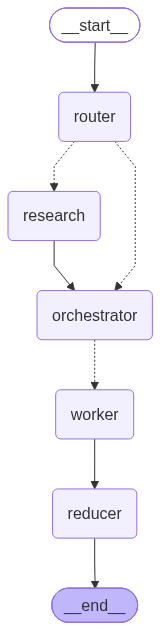

In [37]:
g = StateGraph(State)
g.add_node("router", router_node)
g.add_node("research", research_node)
g.add_node("orchestrator", orchestrator)
g.add_node("worker", worker_node)
g.add_node("reducer", reducer)

g.add_edge(START, "router")
g.add_conditional_edges("router", route_next, {"research": "research", "orchestrator": "orchestrator"})
g.add_edge("research", "orchestrator")

g.add_conditional_edges("orchestrator", fanout, ["worker"])
g.add_edge("worker", "reducer")
g.add_edge("reducer", END)

app = g.compile()
app

In [38]:
for event in app.stream(
    {
        "topic": "Write a blog on cricket"
    },
    stream_mode="updates"
):
    print("\n==============================")
    print("NODE:", list(event.keys())[0])
    print("==============================")

    print(event)


NODE: router
{'router': {'needs_research': False, 'mode': 'closed_book', 'queries': []}}
Generating blog plan for topic: Write a blog on cricket
{'topic': 'Write a blog on cricket', 'mode': 'closed_book', 'needs_research': False, 'queries': [], 'sections': []}

NODE: orchestrator
{'orchestrator': {'plan': Plan(blog_title='The Timeless Appeal of Cricket: From Village Greens to Global Arenas', audience='General readers interested in cricket', tasks=[Task(id=1, title='A Brief History and Evolution of Cricket', brief="Outline cricket's origins in 16th‑century England, its spread through the British Empire, and key milestones that shaped the modern game, including the introduction of limited‑overs formats."), Task(id=2, title='Why Cricket Captivates Millions Today', brief="Explore the sport's unique blend of strategy, skill, and culture—covering formats (Test, ODI, T20), iconic rivalries, fan rituals, and the role of technology and media in expanding its global reach.")])}}

NODE: worker
{

In [53]:
question = "What are the recent developments in Indian Stock Market?"
output = app.invoke({"topic":question })

Generating blog plan for topic: What are the recent developments in Indian Stock Market?
{'topic': 'What are the recent developments in Indian Stock Market?', 'mode': 'open_book', 'needs_research': True, 'queries': ['Indian stock market major index movements and top gainers/losers in the past week (July 2026)', 'Recent regulatory changes and policy announcements affecting the Indian securities market as of July 2026'], 'evidence': [EvidenceItem(title='India market review - July 2026\nThe Indian stock market staged a strong recovery marking its second consecutive month of gains. The market was characterized by high volatility—driven primarily by… | Gunnar Pahlson', url='https://www.linkedin.com/posts/gunnar-pahlson-0151096_india-market-review-july-2026-the-indian-activity-7490057617172488194-1xYK', published_at=None, snippet='Information Technology emerged as the top-performing sector, with the Nifty IT index surging more than 3%. Infosys and Tata Consultancy Services led gains in the I

In [54]:
llm_title = ChatGroq(
    model="openai/gpt-oss-120b",
    temperature=0.9
)

response = llm_title.invoke(
    [
        SystemMessage(
            content="Generate a concise and engaging blog title."
        ),
        HumanMessage(
            content=f"Topic: {question}"
        )
    ]
)

title = response.content

print(title)

India’s Stock Market Surge: Key Trends & Fresh Developments】


In [55]:
from pathlib import Path
import re

# Create folder
output_dir = Path("blogs_generated_new")
output_dir.mkdir(parents=True, exist_ok=True)

# Make title filename-safe
safe_title = re.sub(
    r"[^a-zA-Z0-9]+",
    "_",
    title
).strip("_").lower()

# Create filename
filename = f"{safe_title}_blog.md"

# Create file path
output_path = output_dir / filename

# Write content
output_path.write_text(
    output["final"],
    encoding="utf-8"
)

print(f"Saved to: {output_path.resolve()}")

Saved to: D:\Lang Graph\Agentic-AI-LANGRAPH\8_Planning Agents\blogs_generated_new\india_s_stock_market_surge_key_trends_fresh_developments_blog.md


In [51]:
output_path

WindowsPath('blogs_generated_new/blog.md')